# Elliptic Bitcoin Dataset — Data Preprocessing

**Contributor:** Dhruvi Kadhiwala

This notebook prepares the Elliptic Bitcoin transaction dataset for machine learning. The preprocessing pipeline includes loading and inspecting the raw data, merging transaction features with class labels, handling unlabeled observations, examining missing values and outliers, preparing features for modeling, creating temporal train/validation/test splits, and preparing the transaction network for graph-based models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("elliptic_bitcoin_dataset")

FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATA_DIR / "elliptic_txs_edgelist.csv"

In [3]:
# The features file contains:
# transaction ID + time step + 165 transaction features
feature_columns = (
    ["txId", "time_step"] +
    [f"feature_{i}" for i in range(1, 166)]
)

features = pd.read_csv(
    FEATURES_PATH,
    header=None,
    names=feature_columns
)

classes = pd.read_csv(CLASSES_PATH)
edges = pd.read_csv(EDGES_PATH)

In [4]:
print("Features shape:", features.shape)
print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

display(features.head())
display(classes.head())
display(edges.head())

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_156,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


***Initial Data Inspection***

Before preprocessing, we inspect the dataset for duplicate transactions, missing values, class distribution, and temporal coverage. This establishes the condition of the raw data and helps determine which preprocessing steps are necessary.

In [5]:
print("Duplicate transaction IDs in features:", features["txId"].duplicated().sum())
print("Duplicate transaction IDs in classes:", classes["txId"].duplicated().sum())

print("\nMissing values:")
print("Features:", features.isna().sum().sum())
print("Classes:", classes.isna().sum().sum())
print("Edges:", edges.isna().sum().sum())

Duplicate transaction IDs in features: 0
Duplicate transaction IDs in classes: 0

Missing values:
Features: 0
Classes: 0
Edges: 0


In [6]:
class_counts = classes["class"].value_counts(dropna=False)

print("Class distribution:")
print(class_counts)

print("\nClass percentages:")
print((class_counts / len(classes) * 100).round(2))

Class distribution:
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

Class percentages:
class
unknown    77.15
2          20.62
1           2.23
Name: count, dtype: float64


In [7]:
print("Number of unique time steps:", features["time_step"].nunique())
print("Minimum time step:", features["time_step"].min())
print("Maximum time step:", features["time_step"].max())

transactions_per_step = (
    features["time_step"]
    .value_counts()
    .sort_index()
)

display(transactions_per_step)

Number of unique time steps: 49
Minimum time step: 1
Maximum time step: 49


time_step
1     7880
2     4544
3     6621
4     5693
5     6803
6     4328
7     6048
8     4457
9     4996
10    6727
11    4296
12    2047
13    4528
14    2022
15    3639
16    2975
17    3385
18    1976
19    3506
20    4291
21    3537
22    5894
23    4165
24    4592
25    2314
26    2523
27    1089
28    1653
29    4275
30    2483
31    2816
32    4525
33    3151
34    2486
35    5507
36    6393
37    3306
38    2891
39    2760
40    4481
41    5342
42    7140
43    5063
44    4975
45    5598
46    3519
47    5121
48    2954
49    2454
Name: count, dtype: int64

In [8]:
feature_ids = set(features["txId"])
class_ids = set(classes["txId"])

print("Feature transaction IDs:", len(feature_ids))
print("Class transaction IDs:", len(class_ids))

print(
    "Feature IDs without a class entry:",
    len(feature_ids - class_ids)
)

print(
    "Class IDs without feature data:",
    len(class_ids - feature_ids)
)

edge_ids = set(edges["txId1"]) | set(edges["txId2"])

print(
    "\nTransactions appearing in edge list:",
    len(edge_ids)
)

print(
    "Edge-list IDs without feature data:",
    len(edge_ids - feature_ids)
)

Feature transaction IDs: 203769
Class transaction IDs: 203769
Feature IDs without a class entry: 0
Class IDs without feature data: 0

Transactions appearing in edge list: 203769
Edge-list IDs without feature data: 0


***Label Processing***

The Elliptic dataset contains three label values: `1` for illicit transactions, `2` for licit transactions, and `unknown` for transactions without a ground-truth label.

For supervised model training and evaluation, only transactions with known labels can be used as targets. However, unlabeled transactions are retained in the full graph because they still contribute information about the network structure and may be useful for graph-based models.

For interpretability, the labeled classes are converted to a binary target where:

- `1` = illicit
- `0` = licit
- `NaN` = unknown/unlabeled

In [9]:
label_map = {
    "1": 1,   # illicit
    "2": 0    # licit
}

classes["target"] = classes["class"].map(label_map)

print(classes["target"].value_counts(dropna=False))

target
NaN    157205
0.0     42019
1.0      4545
Name: count, dtype: int64


In [10]:
data = features.merge(
    classes[["txId", "target"]],
    on="txId",
    how="left",
    validate="one_to_one"
)

print("Full dataset shape:", data.shape)
display(data.head())

Full dataset shape: (203769, 168)


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,target
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,NaN
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,NaN
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,0.0
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,NaN


In [11]:
labeled_data = data[data["target"].notna()].copy()

labeled_data["target"] = labeled_data["target"].astype(int)

print("Full graph dataset:", data.shape)
print("Labeled dataset:", labeled_data.shape)

print("\nLabeled class distribution:")
print(labeled_data["target"].value_counts())

print("\nLabeled class percentages:")
print(
    (labeled_data["target"].value_counts(normalize=True) * 100)
    .round(2)
)

Full graph dataset: (203769, 168)
Labeled dataset: (46564, 168)

Labeled class distribution:
target
0    42019
1     4545
Name: count, dtype: int64

Labeled class percentages:
target
0    90.24
1     9.76
Name: proportion, dtype: float64


***Temporal Distribution of Labeled Transactions***

Because transaction behavior can change over time, the dataset is split chronologically rather than randomly. A temporal split better represents the intended real-world setting: models are trained using historical transactions and evaluated on later, previously unseen transactions.

Before selecting the train, validation, and test boundaries, we examine the number of licit and illicit labeled transactions available at each time step.

In [12]:
labels_by_time = (
    labeled_data
    .groupby(["time_step", "target"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={0: "licit", 1: "illicit"})
)

labels_by_time["total"] = (
    labels_by_time["licit"] + labels_by_time["illicit"]
)

labels_by_time["illicit_pct"] = (
    labels_by_time["illicit"] / labels_by_time["total"] * 100
).round(2)

display(labels_by_time)

target,licit,illicit,total,illicit_pct
time_step,,,,
1,2130,17,2147,0.79
2,1099,18,1117,1.61
3,1268,11,1279,0.86
4,1410,30,1440,2.08
5,1874,8,1882,0.43
6,480,5,485,1.03
7,1101,102,1203,8.48
8,1098,67,1165,5.75
9,530,248,778,31.88


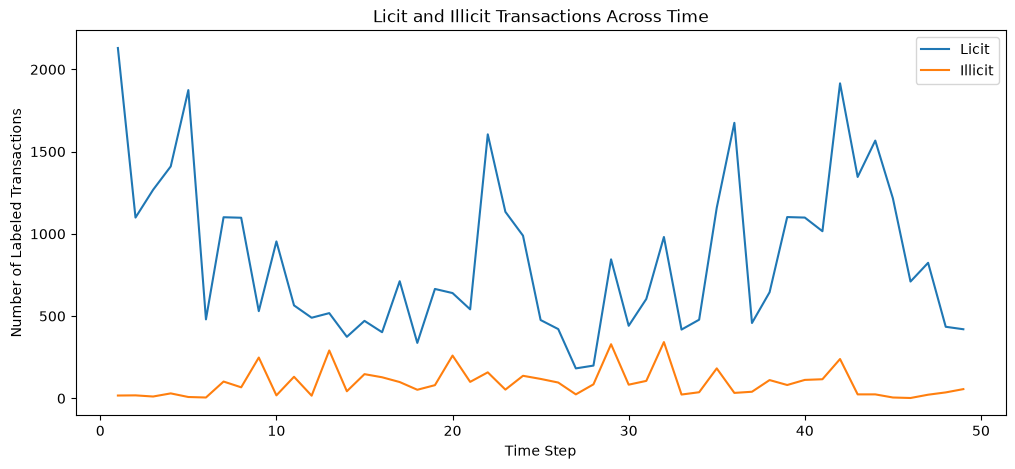

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    labels_by_time.index,
    labels_by_time["licit"],
    label="Licit"
)

plt.plot(
    labels_by_time.index,
    labels_by_time["illicit"],
    label="Illicit"
)

plt.xlabel("Time Step")
plt.ylabel("Number of Labeled Transactions")
plt.title("Licit and Illicit Transactions Across Time")
plt.legend()

plt.show()

In [14]:
train_candidate = labeled_data[
    labeled_data["time_step"] <= 34
]

val_candidate = labeled_data[
    labeled_data["time_step"].between(35, 41)
]

test_candidate = labeled_data[
    labeled_data["time_step"] >= 42
]

def summarize_split(name, df):
    counts = df["target"].value_counts().reindex([0, 1], fill_value=0)

    print(f"{name}")
    print(f"  Total: {len(df):,}")
    print(f"  Licit: {counts[0]:,}")
    print(f"  Illicit: {counts[1]:,}")
    print(f"  Illicit %: {counts[1] / len(df) * 100:.2f}%")
    print()

summarize_split("Training candidate (1-34)", train_candidate)
summarize_split("Validation candidate (35-41)", val_candidate)
summarize_split("Test candidate (42-49)", test_candidate)

Training candidate (1-34)
  Total: 29,894
  Licit: 26,432
  Illicit: 3,462
  Illicit %: 11.58%

Validation candidate (35-41)
  Total: 7,829
  Licit: 7,154
  Illicit: 675
  Illicit %: 8.62%

Test candidate (42-49)
  Total: 8,841
  Licit: 8,433
  Illicit: 408
  Illicit %: 4.61%



***Temporal Train, Validation, and Test Split***

To prevent temporal leakage and better simulate deployment on future transactions, the labeled data is divided chronologically rather than randomly.

- Training set: time steps 1–34
- Validation set: time steps 35–41
- Test set: time steps 42–49

This produces 29,894 labeled training transactions, 7,829 validation transactions, and 8,841 test transactions.

The proportion of illicit transactions decreases from 11.58% in training to 8.62% in validation and 4.61% in testing. We intentionally preserve this shift rather than artificially balancing the validation or test sets because it reflects changes in the observed class distribution over time. Class imbalance will instead be addressed during model training and through appropriate evaluation metrics.

In [15]:
train_data = labeled_data[
    labeled_data["time_step"] <= 34
].copy()

val_data = labeled_data[
    labeled_data["time_step"].between(35, 41)
].copy()

test_data = labeled_data[
    labeled_data["time_step"] >= 42
].copy()

print("Training set:", train_data.shape)
print("Validation set:", val_data.shape)
print("Test set:", test_data.shape)

print(
    "\nTotal labeled examples across splits:",
    len(train_data) + len(val_data) + len(test_data)
)

Training set: (29894, 168)
Validation set: (7829, 168)
Test set: (8841, 168)

Total labeled examples across splits: 46564


In [16]:
feature_cols = [
    col for col in labeled_data.columns
    if col.startswith("feature_")
]

X_train = train_data[feature_cols].copy()
y_train = train_data["target"].copy()

X_val = val_data[feature_cols].copy()
y_val = val_data["target"].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data["target"].copy()

print("Number of predictive features:", len(feature_cols))

print("\nX_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Number of predictive features: 165

X_train: (29894, 165)
X_val: (7829, 165)
X_test: (8841, 165)

y_train: (29894,)
y_val: (7829,)
y_test: (8841,)


***Feature Selection***

Transaction ID (`txId`) is excluded from the predictive feature set because it is an identifier rather than a meaningful transaction characteristic. The `time_step` variable is used to construct the chronological data splits but is not included among the transaction features used for prediction.

The resulting predictive feature set contains 165 anonymized transaction features supplied by the Elliptic dataset. At this stage, all 165 transaction features are retained because the features have already been constructed for transaction-level and neighborhood-level analysis, and there is not yet sufficient evidence to justify removing individual features. Feature relevance will be examined further through exploratory analysis and model-based importance methods.

In [17]:
feature_stats = X_train.describe().T

display(
    feature_stats[
        ["mean", "std", "min", "25%", "50%", "75%", "max"]
    ].head(20)
)

,mean,std,min,25%,50%,75%,max
feature_1,-0.081301,0.554664,-0.172982,-0.172604,-0.170459,-0.147889,21.463992
feature_2,-0.070584,0.549694,-0.210553,-0.182568,-0.158783,-0.104667,25.674475
feature_3,-0.237289,1.018211,-1.756361,-1.201369,-0.646376,1.018602,2.128587
feature_4,0.149141,1.584176,-0.121970,-0.121970,-0.046932,0.028105,49.027598
feature_5,0.042753,2.082395,-0.063725,-0.043875,-0.043875,-0.043875,260.090707
feature_6,0.157080,1.569308,-0.113002,-0.113002,-0.029140,-0.029140,54.565178
feature_7,-0.011197,0.610270,-0.061584,-0.061584,-0.061584,-0.061584,44.365651
feature_8,-0.103235,0.468787,-0.163646,-0.163626,-0.163431,-0.159844,20.323192
feature_9,-0.086280,0.530061,-0.169460,-0.169162,-0.167399,-0.150295,21.102877
feature_10,0.104942,1.744420,-0.049707,-0.049707,-0.049707,-0.038846,189.186944


In [18]:
print("Mean of feature means:", feature_stats["mean"].mean())
print("Mean of feature standard deviations:", feature_stats["std"].mean())

print("\nFeature standard deviation range:")
print("Minimum:", feature_stats["std"].min())
print("Maximum:", feature_stats["std"].max())

Mean of feature means: 0.09187145497441943
Mean of feature standard deviations: 1.3163124685153387

Feature standard deviation range:
Minimum: 0.009013550742080838
Maximum: 2.5536651031757174


***Feature Scaling and Outlier Treatment***

The Elliptic dataset provides 165 anonymized, preprocessed transaction features. Inspection of the training data shows that the features are already represented on transformed numerical scales, although their distributions and variances differ.

Several features contain highly skewed distributions and extreme values. These observations are not automatically removed or clipped because extreme transaction behavior may contain meaningful information for detecting illicit activity. Removing such observations solely on the basis of statistical extremity could eliminate important fraud-related signals.

Therefore, no additional global normalization, outlier removal, or winsorization is applied during this preprocessing stage. Distributional patterns and potential outliers are examined further during exploratory data analysis. Any additional scaling required by a specific model will be fit using only the training data to prevent information leakage.

***Categorical Variable Encoding***

No categorical predictor variables are present in the feature matrix. The 165 supplied transaction features are numerical, so one-hot encoding or other categorical encoding techniques are not required.

The original class labels are converted separately into a binary target variable, where 1 represents an illicit transaction and 0 represents a licit transaction.

***Graph Preparation***

The Elliptic dataset represents Bitcoin transactions as a directed graph. Each transaction is a node, and each directed edge represents the flow of funds from one transaction to another.

The original transaction IDs are arbitrary identifiers rather than consecutive graph indices. To prepare the network for graph-based machine learning, each transaction ID is mapped to a unique integer node index ranging from 0 to 203,768.

All transactions, including those with unknown labels, are retained as graph nodes. Although unlabeled transactions cannot contribute directly to the supervised classification loss, they remain part of the transaction network and preserve potentially useful neighborhood structure.

In [19]:
tx_ids = data["txId"].tolist()

tx_to_node = {
    tx_id: node_idx
    for node_idx, tx_id in enumerate(tx_ids)
}

node_to_tx = {
    node_idx: tx_id
    for tx_id, node_idx in tx_to_node.items()
}

print("Number of mapped nodes:", len(tx_to_node))

print("\nExample mappings:")
for tx_id in tx_ids[:5]:
    print(f"{tx_id} -> {tx_to_node[tx_id]}")

Number of mapped nodes: 203769

Example mappings:
230425980 -> 0
5530458 -> 1
232022460 -> 2
232438397 -> 3
230460314 -> 4


In [20]:
graph_edges = edges.copy()

graph_edges["source"] = graph_edges["txId1"].map(tx_to_node)
graph_edges["target"] = graph_edges["txId2"].map(tx_to_node)

print("Original number of edges:", len(edges))
print("Mapped number of edges:", len(graph_edges))

print(
    "Missing source mappings:",
    graph_edges["source"].isna().sum()
)

print(
    "Missing target mappings:",
    graph_edges["target"].isna().sum()
)

display(graph_edges.head())

Original number of edges: 234355
Mapped number of edges: 234355
Missing source mappings: 0
Missing target mappings: 0


,txId1,txId2,source,target
0,230425980,5530458,0,1
1,232022460,232438397,2,3
2,230460314,230459870,4,5
3,230333930,230595899,6,7
4,232013274,232029206,8,9


In [21]:
print("Number of nodes:", len(tx_to_node))
print("Number of directed edges:", len(graph_edges))

print(
    "Unique source nodes:",
    graph_edges["source"].nunique()
)

print(
    "Unique target nodes:",
    graph_edges["target"].nunique()
)

self_loops = (
    graph_edges["source"] == graph_edges["target"]
).sum()

duplicate_edges = graph_edges[
    ["source", "target"]
].duplicated().sum()

print("Self-loops in raw edge list:", self_loops)
print("Duplicate directed edges:", duplicate_edges)

Number of nodes: 203769
Number of directed edges: 234355
Unique source nodes: 166345
Unique target nodes: 148447
Self-loops in raw edge list: 0
Duplicate directed edges: 0


***Node Labels and Temporal Masks***

Graph neural networks operate on the complete transaction network, including labeled and unlabeled nodes. To separate the nodes used for supervised training, validation, and testing, boolean masks are created based on transaction labels and time steps.

The masks follow the same chronological boundaries used for the non-graph models:

- Training mask: labeled transactions from time steps 1–34
- Validation mask: labeled transactions from time steps 35–41
- Test mask: labeled transactions from time steps 42–49

Unlabeled transactions remain in the graph but are excluded from all three supervised evaluation masks.

In [22]:
data["node_idx"] = data["txId"].map(tx_to_node)

print("Missing node indices:", data["node_idx"].isna().sum())
print("Unique node indices:", data["node_idx"].nunique())
print("Node index range:", data["node_idx"].min(), "to", data["node_idx"].max())

Missing node indices: 0
Unique node indices: 203769
Node index range: 0 to 203768


/var/folders/xs/cktdv13x0ys63d0t9x65nw8c0000gn/T/ipykernel_92192/1105404034.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["node_idx"] = data["txId"].map(tx_to_node)


In [23]:
data["train_mask"] = (
    data["target"].notna() &
    (data["time_step"] <= 34)
)

data["val_mask"] = (
    data["target"].notna() &
    data["time_step"].between(35, 41)
)

data["test_mask"] = (
    data["target"].notna() &
    (data["time_step"] >= 42)
)

print("Training nodes:", data["train_mask"].sum())
print("Validation nodes:", data["val_mask"].sum())
print("Test nodes:", data["test_mask"].sum())

print(
    "Total supervised nodes:",
    data[["train_mask", "val_mask", "test_mask"]]
    .sum()
    .sum()
)

Training nodes: 29894
Validation nodes: 7829
Test nodes: 8841
Total supervised nodes: 46564


/var/folders/xs/cktdv13x0ys63d0t9x65nw8c0000gn/T/ipykernel_92192/1310811673.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["train_mask"] = (
/var/folders/xs/cktdv13x0ys63d0t9x65nw8c0000gn/T/ipykernel_92192/1310811673.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["val_mask"] = (
/var/folders/xs/cktdv13x0ys63d0t9x65nw8c0000gn/T/ipykernel_92192/1310811673.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Cons

In [24]:
train_val_overlap = (
    data["train_mask"] & data["val_mask"]
).sum()

train_test_overlap = (
    data["train_mask"] & data["test_mask"]
).sum()

val_test_overlap = (
    data["val_mask"] & data["test_mask"]
).sum()

unlabeled_in_masks = (
    data["target"].isna() &
    (
        data["train_mask"] |
        data["val_mask"] |
        data["test_mask"]
    )
).sum()

print("Train/validation overlap:", train_val_overlap)
print("Train/test overlap:", train_test_overlap)
print("Validation/test overlap:", val_test_overlap)
print("Unlabeled nodes assigned to a mask:", unlabeled_in_masks)

Train/validation overlap: 0
Train/test overlap: 0
Validation/test overlap: 0
Unlabeled nodes assigned to a mask: 0


In [25]:
for split_name, mask_name in [
    ("Train", "train_mask"),
    ("Validation", "val_mask"),
    ("Test", "test_mask")
]:
    split = data[data[mask_name]]

    counts = (
        split["target"]
        .value_counts()
        .reindex([0, 1], fill_value=0)
    )

    print(f"{split_name}:")
    print(f"  Total = {len(split):,}")
    print(f"  Licit = {counts[0]:,}")
    print(f"  Illicit = {counts[1]:,}")
    print(f"  Illicit % = {counts[1] / len(split) * 100:.2f}%")
    print()

Train:
  Total = 29,894
  Licit = 26,432
  Illicit = 3,462
  Illicit % = 11.58%

Validation:
  Total = 7,829
  Licit = 7,154
  Illicit = 675
  Illicit % = 8.62%

Test:
  Total = 8,841
  Licit = 8,433
  Illicit = 408
  Illicit % = 4.61%



In [26]:
# Create a contiguous copy to remove DataFrame fragmentation
data = data.copy()

In [27]:
node_time = data.set_index("node_idx")["time_step"]

graph_edges["source_time"] = graph_edges["source"].map(node_time)
graph_edges["target_time"] = graph_edges["target"].map(node_time)

display(graph_edges.head())

print(
    "Missing source time steps:",
    graph_edges["source_time"].isna().sum()
)

print(
    "Missing target time steps:",
    graph_edges["target_time"].isna().sum()
)

,txId1,txId2,source,target,source_time,target_time
0,230425980,5530458,0,1,1,1
1,232022460,232438397,2,3,1,1
2,230460314,230459870,4,5,1,1
3,230333930,230595899,6,7,1,1
4,232013274,232029206,8,9,1,1


Missing source time steps: 0
Missing target time steps: 0


In [28]:
same_time = (
    graph_edges["source_time"] == graph_edges["target_time"]
).sum()

forward_time = (
    graph_edges["source_time"] < graph_edges["target_time"]
).sum()

backward_time = (
    graph_edges["source_time"] > graph_edges["target_time"]
).sum()

print("Same-time edges:", same_time)
print("Forward-in-time edges:", forward_time)
print("Backward-in-time edges:", backward_time)

print("\nPercentages:")
print(f"Same time: {same_time / len(graph_edges) * 100:.2f}%")
print(f"Forward in time: {forward_time / len(graph_edges) * 100:.2f}%")
print(f"Backward in time: {backward_time / len(graph_edges) * 100:.2f}%")

Same-time edges: 234355
Forward-in-time edges: 0
Backward-in-time edges: 0

Percentages:
Same time: 100.00%
Forward in time: 0.00%
Backward in time: 0.00%


In [29]:
def get_period(time_step):
    if time_step <= 34:
        return "train"
    elif time_step <= 41:
        return "validation"
    else:
        return "test"

graph_edges["source_period"] = (
    graph_edges["source_time"].apply(get_period)
)

graph_edges["target_period"] = (
    graph_edges["target_time"].apply(get_period)
)

edge_periods = pd.crosstab(
    graph_edges["source_period"],
    graph_edges["target_period"]
)

display(edge_periods)

target_period,test,train,validation
source_period,,,
test,42152,0,0
train,0,156843,0
validation,0,0,35360


In [30]:
cross_period_edges = graph_edges[
    graph_edges["source_period"] != graph_edges["target_period"]
]

print("Total edges:", len(graph_edges))
print("Cross-period edges:", len(cross_period_edges))

print(
    "Cross-period percentage:",
    f"{len(cross_period_edges) / len(graph_edges) * 100:.2f}%"
)

display(
    cross_period_edges[
        [
            "source",
            "target",
            "source_time",
            "target_time",
            "source_period",
            "target_period"
        ]
    ].head(10)
)

Total edges: 234355
Cross-period edges: 0
Cross-period percentage: 0.00%


,source,target,source_time,target_time,source_period,target_period


***Temporal Graph Integrity***

The temporal structure of the transaction graph was examined to determine whether graph edges could introduce information from future periods into earlier training periods.

All 234,355 directed edges connect transactions within the same time step. There are no edges connecting transactions across different time steps and, consequently, no edges crossing the training, validation, or test boundaries.

The resulting graph contains:

- 156,843 edges within the training period
- 35,360 edges within the validation period
- 42,152 edges within the test period
- 0 edges crossing between temporal splits

This structure supports chronological evaluation without graph connections directly linking training transactions to future validation or test transactions.

In [31]:
node_features = data[feature_cols].to_numpy(dtype=np.float32)

print("Node feature matrix shape:", node_features.shape)
print("Node feature dtype:", node_features.dtype)

Node feature matrix shape: (203769, 165)
Node feature dtype: float32


In [32]:
edge_index = graph_edges[
    ["source", "target"]
].to_numpy(dtype=np.int64).T

print("Edge index shape:", edge_index.shape)
print("Edge index dtype:", edge_index.dtype)

print("\nFirst 5 edges:")
print(edge_index[:, :5])

Edge index shape: (2, 234355)
Edge index dtype: int64

First 5 edges:
[[0 2 4 6 8]
 [1 3 5 7 9]]


In [33]:
node_labels = (
    data["target"]
    .fillna(-1)
    .to_numpy(dtype=np.int64)
)

print("Node labels shape:", node_labels.shape)

unique_labels, label_counts = np.unique(
    node_labels,
    return_counts=True
)

print("\nNode label counts:")

for label, count in zip(unique_labels, label_counts):
    print(label, count)

Node labels shape: (203769,)

Node label counts:
-1 157205
0 42019
1 4545


In [34]:
train_mask = data["train_mask"].to_numpy(dtype=bool)
val_mask = data["val_mask"].to_numpy(dtype=bool)
test_mask = data["test_mask"].to_numpy(dtype=bool)

print("Train mask:", train_mask.sum())
print("Validation mask:", val_mask.sum())
print("Test mask:", test_mask.sum())

Train mask: 29894
Validation mask: 7829
Test mask: 8841


In [35]:
assert node_features.shape == (203769, 165)
assert edge_index.shape == (2, 234355)
assert node_labels.shape == (203769,)

assert train_mask.sum() == 29894
assert val_mask.sum() == 7829
assert test_mask.sum() == 8841

assert not np.any(train_mask & val_mask)
assert not np.any(train_mask & test_mask)
assert not np.any(val_mask & test_mask)

assert np.all(node_labels[train_mask] != -1)
assert np.all(node_labels[val_mask] != -1)
assert np.all(node_labels[test_mask] != -1)

assert edge_index.min() >= 0
assert edge_index.max() < len(data)

print("All preprocessing integrity checks passed.")

All preprocessing integrity checks passed.


## Preprocessing Summary

The preprocessing pipeline produced a graph containing 203,769 transaction nodes, 234,355 directed edges, and 165 numerical features per node.

No missing values or duplicate transaction IDs were identified. Of the 203,769 transactions, 46,564 have known class labels: 42,019 licit and 4,545 illicit. The remaining 157,205 unlabeled transactions are retained in the graph to preserve network structure but are excluded from supervised training and evaluation.

The labeled transactions were divided chronologically into:

- Training: time steps 1–34 (29,894 transactions)
- Validation: time steps 35–41 (7,829 transactions)
- Testing: time steps 42–49 (8,841 transactions)

The illicit class represents 11.58% of the training set, 8.62% of the validation set, and 4.61% of the test set, demonstrating temporal variation in class prevalence.

All 165 supplied numerical transaction features were retained. Transaction IDs were excluded as predictive features, while time steps were used to construct the chronological splits. No additional global scaling or outlier removal was applied during preprocessing.

For graph-based modeling, transaction IDs were mapped to consecutive node indices. The final GNN-ready representation contains a node feature matrix of shape (203,769, 165), an edge index of shape (2, 234,355), node labels, and boolean training, validation, and test masks. All graph edges connect transactions within the same time step, with no edges crossing the temporal split boundaries.